# Human Value Classification with `pyvalues`

## Learning Objectives

By the end of this tutorial, you will be able to

1. Detect Schwartz' values in natural language text using different classifiers
2. Get an overview of the values in different texts
3. Evaluate classifications against a ground truth

## Target Audience

This tutorial is aimed at beginners with some knowledge of programming.

## Duration

About half a work day.

## Use Cases

- To analyze which human values different groups (e.g., media of different countries) associate with the same topic, acquire texts (e.g., news articles) on this topic written by the different groups, classify the texts by human values, and compare the relative frequencies of the human values between the texts of the groups. This use case was the inspiration for the [ValuesML project](https://knowledge4policy.ec.europa.eu/projects-activities/valuesml-unravelling-expressed-values-media-informed-policy-making_en).
- To identify the human values that are important to a specific group, classify texts of that group (e.g., manifestos, opinion pieces) and visualize the relative frequencies of the human values.

## Environment Setup

First, check whether a graphics card is available. If you are using an online virtual environment that supports graphics cards and would like to use one (very useful for the ValueEval'24 classifier, but not required), and none is found, check whether you need to enable it first. For example, here are instructions for [Google Colab](https://colab.research.google.com/notebooks/gpu.ipynb).

In [1]:
import subprocess
gpu_memory_free = 0
try:
  command = "nvidia-smi --query-gpu=memory.free --format=csv"
  command_output = subprocess.check_output(command.split()).decode('ascii')
  memory_free_info = command_output.split('\n')[:-1][1:]
  memory_free_values = [
    int(x.split()[0]) for i, x in enumerate(memory_free_info)
  ]
  if len(memory_free_values) > 0:
    gpu_memory_free = memory_free_values[0] / 1024
except FileNotFoundError:
  pass

if gpu_memory_free > 0:
  print(f"Found graphics card with {gpu_memory_free} GB memory")
else:
  print("No graphics card found.")

Found graphics card with 14.5634765625 GB memory


The tutorial is based on the `pyvalues` library.

In [2]:
#| output: false
!pip install pyvalues==0.10.0
import pyvalues

## Value Schemas

The original 10 human values were later refined to 19 human values in a hierarchical structure - for example, "Self-direction" was refined into "Self-direction: action" and "Self-direction: thought"; but also the values "Face" and "Humility" were added (Schwartz et al., 2012).

Thus there are three schemas that are typically used in value research. When selecting the schema to use for one's work, one has to consider that not all classification algorithms/model support all of these schemas. The schemas in `pyvalues` are:

In [3]:
# The 10 original values
print(pyvalues.OriginalValues.names())

['Self-direction', 'Stimulation', 'Hedonism', 'Achievement', 'Power', 'Security', 'Tradition', 'Conformity', 'Benevolence', 'Universalism']


In [4]:
# The 19 refined values
print(pyvalues.RefinedValues.names())

['Self-direction: action', 'Self-direction: thought', 'Stimulation', 'Hedonism', 'Achievement', 'Power: dominance', 'Power: resources', 'Face', 'Security: personal', 'Security: societal', 'Tradition', 'Conformity: rules', 'Conformity: interpersonal', 'Humility', 'Benevolence: caring', 'Benevolence: dependability', 'Universalism: concern', 'Universalism: nature', 'Universalism: tolerance']


In [5]:
# The 12 values when collapsing the 19 refined ones = the 10 original values plus "Face" and "Humility"
print(pyvalues.RefinedCoarseValues.names())

['Self-direction', 'Stimulation', 'Hedonism', 'Achievement', 'Power', 'Face', 'Security', 'Tradition', 'Conformity', 'Humility', 'Benevolence', 'Universalism']


In computational analyses, one typically assigns a "score" to texts for the each value of the selected schema. Such scores indicate a prevalence, confidence, or similar. Scores range from 0 (weakest) to 1 (strongest).

The following code illustrates how to set value scores.

In [6]:
scores = pyvalues.RefinedValues(self_direction_action=0.5, self_direction_thought=0.25, face=0.5)

print(f"Refined:        {scores}")
print(f"Refined coarse: {scores.coarse_values()}") # taking maximum of refined
print(f"Original:       {scores.original_values()}") # same and no "Face" nor "Humility"

Refined:        {"Self-direction: thought":0.25,"Self-direction: action":0.5,"Face":0.5}
Refined coarse: {"Self-direction":0.5,"Face":0.5}
Original:       {"Self-direction":0.5}


Some classifiers also distinguish between a text indicating whether a text (partially) attains the value or (partially) constrains the value. Such a distinction is available for each of the three schemas using the schema suffix "WithAttainment":

In [7]:
# The 38 scores for 19 refined values (attained and constrained each)
print(pyvalues.RefinedValuesWithAttainment.names())
print()

scores = pyvalues.RefinedValuesWithAttainment(
  self_direction_action=pyvalues.values.AttainmentScore(attained=0.5),
  self_direction_thought=pyvalues.values.AttainmentScore(constrained=0.25),
  face=pyvalues.values.AttainmentScore(constrained=0.25),
)

print(f"Refined:                 {scores}")
print(f"Refined coarse:          {scores.coarse_values()}") # taking maximum, keep ratio of attained and constrained
print(f"Original:                {scores.original_values()}") # also no "Face" nor "Humility"
print()
print(f"Refined (no attainment): {scores.without_attainment()}") # sums scores for attained and constrained

['Self-direction: action attained', 'Self-direction: action constrained', 'Self-direction: thought attained', 'Self-direction: thought constrained', 'Stimulation attained', 'Stimulation constrained', 'Hedonism attained', 'Hedonism constrained', 'Achievement attained', 'Achievement constrained', 'Power: dominance attained', 'Power: dominance constrained', 'Power: resources attained', 'Power: resources constrained', 'Face attained', 'Face constrained', 'Security: personal attained', 'Security: personal constrained', 'Security: societal attained', 'Security: societal constrained', 'Tradition attained', 'Tradition constrained', 'Conformity: rules attained', 'Conformity: rules constrained', 'Conformity: interpersonal attained', 'Conformity: interpersonal constrained', 'Humility attained', 'Humility constrained', 'Benevolence: caring attained', 'Benevolence: caring constrained', 'Benevolence: dependability attained', 'Benevolence: dependability constrained', 'Universalism: concern attained',

## Data Loading

This tutorial uses a few small example texts ("documents") to illustrate the classification process.

### Segmentation

Frequently, instead of segments one has longer text to be classified, but classifiers assign value scores per sentence, not per document. To this end, the following lines prepare an effective and efficient sentence segmentation method (`split_into_sentences`) using [sentencex](https://github.com/wikimedia/sentencex):

In [8]:
#| output: false
!pip install sentencex
import sentencex

# define method to split text into sentences (using appropriate model for each language)
def split_into_sentences(text, language="en"):
  return [sentence.strip() for sentence in sentencex.segment(language, text)]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 66.6 MB/s eta 0:00:00


We then prepare the segments:

In [9]:
document1_segments = split_into_sentences(
      "We have to be the best at this. Otherwise we will loose the respect of the others and control.",
      "en"
    )
document2_segments = split_into_sentences(
      "Wir müssen die Umwelt beschützen.",  # German for: "We have to protect the environment"
      "de"
    )
print(document1_segments)
print(document2_segments)

['We have to be the best at this.', 'Otherwise we will loose the respect of the others and control.']
['Wir müssen die Umwelt beschützen.']


To classify complete texts, they have to be first segmented into sentences.



### Ground Truth

We also define "ground truth" values that we expect the classifier to predict. In later sections, this tutorial shows how to evaluate the classifier against these true values.

In [10]:
document1_ground_truth_value_scores = [
      pyvalues.OriginalValues.from_labels(["Achievement"]),
      pyvalues.OriginalValues.from_labels(["Achievement", "Power"])
    ]
document2_ground_truth_value_scores = [
      pyvalues.OriginalValues.from_labels(["Universalism"])
    ]
print(document1_ground_truth_value_scores)
print(document2_ground_truth_value_scores)

[OriginalValues(self_direction=0.0, stimulation=0.0, hedonism=0.0, achievement=1.0, power=0.0, security=0.0, tradition=0.0, conformity=0.0, benevolence=0.0, universalism=0.0), OriginalValues(self_direction=0.0, stimulation=0.0, hedonism=0.0, achievement=1.0, power=1.0, security=0.0, tradition=0.0, conformity=0.0, benevolence=0.0, universalism=0.0)]
[OriginalValues(self_direction=0.0, stimulation=0.0, hedonism=0.0, achievement=0.0, power=0.0, security=0.0, tradition=0.0, conformity=0.0, benevolence=0.0, universalism=1.0)]


### Document Classes

The `pyvalues.ValuesAnnotatedDocument[schema]` class is used to represent documents with associated values. If ground truth values are not available, use the `pyvalues.Document` instead of `pyvalues.ValuesAnnotatedDocument[schema]` (it is the same without `values` attribute).

In [11]:
documents = [
  pyvalues.ValuesAnnotatedDocument[pyvalues.OriginalValues](
    id="doc1",
    language="en",
    segments=document1_segments,
    values=document1_ground_truth_value_scores
  ),
  pyvalues.ValuesAnnotatedDocument[pyvalues.OriginalValues](
    id="doc2",
    language="de",
    segments=document2_segments,
    values=document2_ground_truth_value_scores
  )
]

for document in documents:
  print(document.model_dump_json(indent=2, exclude_defaults=True))

{
  "id": "doc1",
  "segments": [
    "We have to be the best at this.",
    "Otherwise we will loose the respect of the others and control."
  ],
  "values": [
    {
      "Achievement": 1.0
    },
    {
      "Achievement": 1.0,
      "Power": 1.0
    }
  ]
}
{
  "id": "doc2",
  "language": "de",
  "segments": [
    "Wir müssen die Umwelt beschützen."
  ],
  "values": [
    {
      "Universalism": 1.0
    }
  ]
}


Alternatively, you can use your own data. Online interactive environments typically allow to upload files via the file browser (in the same or a similar way to [JupyterLab](https://jupyterlab.readthedocs.io/en/stable/user/files.html#uploading-and-downloading)).

## Classifying


Value classifiers are computational methods that detect human values in text. For each sentence, they predict a score for each value
* A score close to 0 means the classifier is confident in predicting that the sentence does not refer to (or attain or constrain) the value.
* A score close to 1 means the classifier is confident in predicting that the sentence refers to (or attains or constrains) the value.
* A score between 0 and 1 means the classifier places its confidence in-between, with a score 0.5 meaning the classifier is absolutely unsure.

All `Classifying with ...` subsections can be skipped. At least one must be executed, though.

For this tutorial, we collect classifications by the different classifiers in `classifications_by` with the respective classifier name as key.

In [12]:
classifications_by = {}

### Classifying with the Dictionary Classifier

This methods looks if the text contains a word from a predefined list ("dictionary") that indicates a specific value. The dictionaries for each value were developed by Ponizovskiy et al. (2020).

In [13]:
from pyvalues.dictionary_classifier import OriginalValuesDictionaryClassifier
dictionary_classifier = OriginalValuesDictionaryClassifier.get_default(
    score_threshold = 1, # sets how often words from a dictionary have to occur in a text for it to be classified as indicating the value
    max_values = 0  # If not 0, at most this many values are classified (ranked by how often words from the dictionary occur in the text)
)

For illustration, the following line shows 10 words for English that indicate "Achievement".

In [14]:
print([word for word, values in dictionary_classifier._classifiers["en"]._dictionaries.items() if "Achievement" in values][0:10])

['accomplish', 'accomplished', 'achieve', 'achievement', 'achieving', 'advance', 'advancement', 'advantage', 'appreciate', 'appreciation']


A separate dictionary is needed for each language and value. The classifier used here only contains list for the original values and for a few languages:

In [15]:
print(list(dictionary_classifier._classifiers.keys()))

['bg', 'de', 'el', 'en', 'fr', 'it', 'nl']


The `classify_documents_for_original_values`-method can be used to classify the sentences according to the dictionaries. By default, whenever one word from a dictionary occurs, the text is classified as indicating the corresponding value. But this behavior can be changed. Also, own dictionaries can be used by not using `get_default()` but the constructor of `OriginalValuesDictionaryClassifier` (a separate class exists for each value schema).



In [16]:
# get list of documents with classified values
classifications_by["dictionary"] = list(dictionary_classifier.classify_documents_for_original_values(documents))

# print results
for classifications in classifications_by["dictionary"]:
  for index in range(len(classifications.segments)):
    document_id = classifications.id
    segment = classifications.segments[index]
    values = classifications.values[index]
    print(f"{document_id} segment{index+1}: '{segment}' -> {values}")

doc1 segment1: 'We have to be the best at this.' -> {"Achievement":1.0}
doc1 segment2: 'Otherwise we will loose the respect of the others and control.' -> {"Achievement":1.0,"Power":1.0,"Conformity":1.0}
doc2 segment1: 'Wir müssen die Umwelt beschützen.' -> {"Universalism":1.0}


### Classifying with the ValueEval'24 Classifier

This approach to classify a text for values is a trained multilingual language model (Legkas et al., 2024). It won the [Touché ValueEval'24 Human Value Detection Task](https://touche.webis.de/clef24/touche24-web/human-value-detection.html). As it sometimes needs the context of a sentence to interpret is properly, this classifier considers for a classification also previous sentences and how they were classified.

The classifier classifies for the 19 refined values with attainment for the 9 languages of the ValueEval'24 task.

Installing and loading the [ValueEval'24 classifier](https://touche.webis.de/publications.html#legkas_2024) (package `valueeval24_hierocles_of_alexandria`) can take several minutes. You can skip this part and skip the "ValueEval'24 Classifier" section below.

The original classifier requires a graphics card with at least 20 GB of memory. If only a smaller graphics card is available, a smaller (less accurate) version will be loaded automatically. If you do not have a graphics card with at least 5 GB of memory, or if you choose not to use it (see below), the classifier will load without a graphics card instead (very slow, but you can still complete this tutorial with it).

In [17]:
#| output: false
!pip install valueeval24-hierocles-of-alexandria==0.10.0
import valueeval24_hierocles_of_alexandria
valueeval24_classifier = valueeval24_hierocles_of_alexandria.ValueEval24Classifier()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.4/59.4 MB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.5/897.5 kB 66.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 124.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 51.4 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.10.1
    Uninstalling huggingface_hub-1.10.1:
      Successfully uninstalled huggingface_hub-1.10.1
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0
Detected GPU with between 10GB and 20GB of memory (namely 14.560546875GB): taking 8bit model


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

...

model-00004-of-00004.safetensors:   0%|          | 0.00/2.18G [00:00<?, ?B/s]

model-00001-of-00004.safetensors:   0%|          | 0.00/4.98G [00:00<?, ?B/s]

model-00002-of-00004.safetensors:   0%|          | 0.00/4.93G [00:00<?, ?B/s]

model-00003-of-00004.safetensors:   0%|          | 0.00/4.90G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

The classifier is available for nine different languages

In [19]:
print(valueeval24_hierocles_of_alexandria.multi_head_model.lang_dict.keys())

dict_keys(['EN', 'EL', 'DE', 'TR', 'FR', 'BG', 'HE', 'IT', 'NL'])


Classification works like for all other classifiers:

In [37]:
# get list of documents with classified values
classifications_by["valueeval24"] = list(valueeval24_classifier.classify_documents_for_refined_values_with_attainment(documents))

# print results
for classifications in classifications_by["valueeval24"]:
  for index in range(len(classifications.segments)):
    document_id = classifications.id
    segment = classifications.segments[index]
    values = classifications.values[index]
    print(f"{document_id} segment{index+1}: '{segment}' -> {values}")

doc1 segment1: 'We have to be the best at this.' -> {"Self-direction: thought":{"attained":0.00843048095703125,"constrained":0.0018148422241210938},"Self-direction: action":{"attained":0.006575584411621094,"constrained":0.0005459785461425781},"Stimulation":{"attained":0.002979278564453125,"constrained":0.0006866455078125},"Hedonism":{"attained":0.00583648681640625,"constrained":0.0009767214457194011},"Achievement":{"attained":0.9568058894230769,"constrained":0.006671905517578125},"Power: dominance":{"attained":0.01669747488839286,"constrained":0.008207956949869793},"Power: resources":{"attained":0.0048542022705078125,"constrained":0.0014352798461914062},"Face":{"attained":0.009860992431640625,"constrained":0.0033926963806152344},"Security: personal":{"attained":0.0039577484130859375,"constrained":0.0037511189778645835},"Security: societal":{"attained":0.0013136863708496094,"constrained":0.0005965232849121094},"Tradition":{"attained":0.002562204996744792,"constrained":0.0011768341064453

This tutorial uses only the 10 original values below, so the scores need to be converted:

In [38]:
for document_index in range(len(classifications_by["valueeval24"])):
    document: pyvalues.ValuesAnnotatedDocument[pyvalues.RefinedValuesWithAttainment] = classifications_by["valueeval24"][document_index]
    values = [vals.convert(pyvalues.OriginalValues) for vals in document.values]
    classifications_by["valueeval24"][document_index] = pyvalues.ValuesAnnotatedDocument[pyvalues.OriginalValues](
        id=document.id,
        language=document.language,
        segments=document.segments,
        values=values
    )
print(classifications_by["valueeval24"])

[ValuesAnnotatedDocument[OriginalValues](id='doc1', language='en', segments=['We have to be the best at this.', 'Otherwise we will loose the respect of the others and control.'], values=[OriginalValues(self_direction=0.010245323181152344, stimulation=0.003665924072265625, hedonism=0.006813208262125651, achievement=0.963477794940655, power=0.024905431838262652, security=0.007708867390950521, tradition=0.0037390391031901045, conformity=0.0059596697489420584, benevolence=0.003144939740498861, universalism=0.006365299224853516), OriginalValues(self_direction=0.015366872151692709, stimulation=0.0081329345703125, hedonism=0.003292219979422433, achievement=0.2574408394949777, power=0.223388671875, security=0.053876241048177086, tradition=0.006141265233357747, conformity=0.20460764567057294, benevolence=0.04386266072591146, universalism=0.007329463958740234)]), ValuesAnnotatedDocument[OriginalValues](id='doc2', language='de', segments=['Wir müssen die Umwelt beschützen.'], values=[OriginalValu

## Working with Classifications

### Saving Classifications

After values are classified, one should store them for future use. We here write a separate file for each classifier:

In [39]:
for classifier, classifications in classifications_by.items():
  with open(f"{classifier}.tsv", "w") as f:
    print(f"Saving {classifier} results to {f.name}")
    writer = pyvalues.OriginalValues.writer_tsv_with_text(f)
    writer.write_documents(classifications)

Saving dictionary results to dictionary.tsv
Saving valueeval24 results to valueeval24.tsv


For example, this is the output for the Dictionary classifier:

In [40]:
!cat dictionary.tsv

ID	Text	Language	Self-direction	Stimulation	Hedonism	Achievement	Power	Security	Tradition	Conformity	Benevolence	Universalism
doc1	We have to be the best at this.	en	0.0	0.0	0.0	1.0	0.0	0.0	0.0	0.0	0.0	0.0
doc1	Otherwise we will loose the respect of the others and control.	en	0.0	0.0	0.0	1.0	1.0	0.0	0.0	1.0	0.0	0.0
doc2	Wir müssen die Umwelt beschützen.	de	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	1.0


If you used this tutorial in an online virtual environment, there is usually a way to browse and download files in the menu on the top or left. Look for a directory symbol.

### Document (Set) Classification by Score Averaging

Some research questions require an analysis of values per document (or even sets of documents) and not per segment. The straightforward way to do so is to average the confidence over all segments:

In [41]:
print("Scores for each segment")
for document_index in range(len(documents)):
  for segment_index in range(len(documents[document_index].segments)):
    print(f"{documents[document_index].id} segment{segment_index+1}")
    for classifier, classifications in classifications_by.items():
      values = classifications[document_index].values[segment_index]
      print(f"- {classifier}: {values}")

print()
print("Scores averaged for each document")
for document_index in range(len(documents)):
  print(f"{documents[document_index].id}")
  for classifier, classifications in classifications_by.items():
    values = pyvalues.OriginalValues.average(classifications[document_index].values)
    print(f"- {classifier}: {values}")

print()
print("Score averaged across documents")
for classifier, classifications in classifications_by.items():
  values = pyvalues.OriginalValues.average_documents(classifications)
  print(f"- {classifier}: {values}")

Scores for each segment
doc1 segment1
- dictionary: {"Achievement":1.0}
- valueeval24: {"Self-direction":0.010245323181152344,"Stimulation":0.003665924072265625,"Hedonism":0.006813208262125651,"Achievement":0.963477794940655,"Power":0.024905431838262652,"Security":0.007708867390950521,"Tradition":0.0037390391031901045,"Conformity":0.0059596697489420584,"Benevolence":0.003144939740498861,"Universalism":0.006365299224853516}
doc1 segment2
- dictionary: {"Achievement":1.0,"Power":1.0,"Conformity":1.0}
- valueeval24: {"Self-direction":0.015366872151692709,"Stimulation":0.0081329345703125,"Hedonism":0.003292219979422433,"Achievement":0.2574408394949777,"Power":0.223388671875,"Security":0.053876241048177086,"Tradition":0.006141265233357747,"Conformity":0.20460764567057294,"Benevolence":0.04386266072591146,"Universalism":0.007329463958740234}
doc2 segment1
- dictionary: {"Universalism":1.0}
- valueeval24: {"Self-direction":0.016810099283854168,"Stimulation":0.004673004150390625,"Hedonism":0.0

### Binarization and Document Frequencies

Typically, one is not interested in values that are classified with a small score. To get only the prevalent values, one can select only those values with a score above a certain threshold by setting these to a score of 1 and the others to a score of 0 ("binarization"). We here use a threshold of 0.1, which corresponds to the value being classified for at least every 10th segment (simplifying here to assume scores of either 0 or 1).

In [52]:
threshold = 0.1

print("Scores averaged and binarized for each document")
for document_index in range(len(documents)):
  print(f"{documents[document_index].id}")
  for classifier, classifications in classifications_by.items():
    values = pyvalues.OriginalValues.average(classifications[document_index].values)
    values_binarized = values.binarize(threshold)
    print(f"- {classifier}: {values_binarized}")

Scores averaged and binarized for each document
doc1
- dictionary: {"Achievement":1.0,"Power":1.0,"Conformity":1.0}
- valueeval24: {"Achievement":1.0,"Power":1.0,"Conformity":1.0}
- all_attained: {"Self-direction":1.0,"Stimulation":1.0,"Hedonism":1.0,"Achievement":1.0,"Power":1.0,"Security":1.0,"Tradition":1.0,"Conformity":1.0,"Benevolence":1.0,"Universalism":1.0}
doc2
- dictionary: {"Universalism":1.0}
- valueeval24: {"Universalism":1.0}
- all_attained: {"Self-direction":1.0,"Stimulation":1.0,"Hedonism":1.0,"Achievement":1.0,"Power":1.0,"Security":1.0,"Tradition":1.0,"Conformity":1.0,"Benevolence":1.0,"Universalism":1.0}
{'dictionary': [ValuesAnnotatedDocument[OriginalValues](id='doc1', language='en', segments=['We have to be the best at this.', 'Otherwise we will loose the respect of the others and control.'], values=[OriginalValues(self_direction=0.0, stimulation=0.0, hedonism=0.0, achievement=1.0, power=0.0, security=0.0, tradition=0.0, conformity=0.0, benevolence=0.0, universalism

The average of the binarized document scores then gives an impression of how prevalent a value is in the entire collection of documents (relative frequencies of document with the value):

In [43]:
relative_document_frequencies = {}

print("Relative document frequencies:")
for classifier in classifications_by.keys():
  values_binarized = []
  for document_index in range(len(documents)):
    values = pyvalues.OriginalValues.average(classifications[document_index].values)
    values_binarized.append(values.binarize(threshold))
  relative_document_frequencies[classifier] = pyvalues.OriginalValues.average(values_binarized)
  print(f"- {classifier}: {relative_document_frequencies[classifier]}")

Relative document frequencies:
- dictionary: {"Achievement":0.5,"Power":0.5,"Conformity":0.5,"Universalism":0.5}
- valueeval24: {"Achievement":0.5,"Power":0.5,"Conformity":0.5,"Universalism":0.5}


Like classifications, one should write results like relative document frequencies to files. Here, we write the frequencies to one file with one line per classifier.

In [46]:
with open("relative_document_frequencies.tsv", "w") as f:
  writer = pyvalues.OriginalValues.writer_tsv(f)
  for classifier, frequencies in relative_document_frequencies.items():
    writer.write(frequencies, record_id=classifier)

!cat relative_document_frequencies.tsv

ID	Self-direction	Stimulation	Hedonism	Achievement	Power	Security	Tradition	Conformity	Benevolence	Universalism
dictionary	0.0	0.0	0.0	0.5	0.5	0.0	0.0	0.5	0.0	0.5
valueeval24	0.0	0.0	0.0	0.5	0.5	0.0	0.0	0.5	0.0	0.5


### Visualizing Frequencies

Instead of writing averages, one can also visualize them to get a direct impression. A radar plot is especially suited to show scores for human values as it matches the circle of the theory.

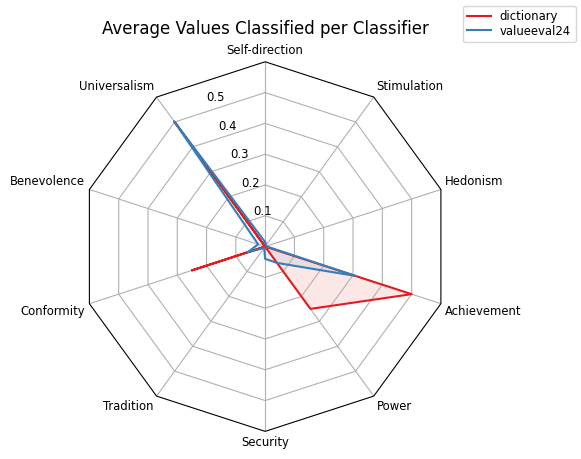

In [48]:
averages = [pyvalues.OriginalValues.average_documents(documents) for documents in classifications_by.values()]
plot = pyvalues.OriginalValues.plot_all(
    averages,
    labels=list(classifications_by.keys()),
    gridlines=[0.1,0.2,0.3,0.4,0.5,0.6]
)
plot.title("Average Values Classified per Classifier", pad=20);

## Evaluating

Evaluation answers the question of well a classifier performed. It relies on a ground truth (see the respective section of `Data Loading`) to judge how often a classifier classified correctly and incorrectly.

To put results into context, it is most often useful to compare them to results obtained with a naive baseline, e.g., a classifier that behaves the same no matter the input. A good baseline for human value classification is the `AllAttainedClassifier`, which classifies each segment as attaining all values.

In [49]:
from pyvalues.baseline_classifier import AllAttainedClassifier
all_attained_classifier = AllAttainedClassifier()
classifications_by["all_attained"] = list(all_attained_classifier.classify_documents_for_original_values(documents))

The [F-score](https://en.wikipedia.org/wiki/F-score) is a typical measure of performance for human value classifications. It condenses performance into a single number. For analyzing errors, however, one should rather inspect its constituents, precision (ratio of predicted values that are correct according to the ground truth) and recall (ratio of values in the ground truth that are also predicted):

In [50]:
fs = {}

for classifier, classifications in classifications_by.items():
  evaluation = pyvalues.OriginalValues.evaluate_documents(classifications, documents)
  num_values_in_ground_truth = len(evaluation.get_values_in_ground_truth())
  f, precision, recall = evaluation.f()
  macro_f = sum(f.to_list()) / num_values_in_ground_truth
  macro_precision = sum(precision.to_list()) / num_values_in_ground_truth
  macro_recall = sum(recall.to_list()) / num_values_in_ground_truth
  print(f'{classifier}')
  print(f'- f:         {macro_f}; {f}')
  print(f'- precision: {macro_precision}; {precision}')
  print(f'- recall:    {macro_recall}; {recall}')
  fs[classifier] = f


dictionary
- f:         1.0; {"Achievement":1.0,"Power":1.0,"Universalism":1.0}
- precision: 1.0; {"Achievement":1.0,"Power":1.0,"Universalism":1.0}
- recall:    1.0; {"Achievement":1.0,"Power":1.0,"Universalism":1.0}
valueeval24
- f:         0.5555555555555555; {"Achievement":0.6666666666666666,"Universalism":1.0}
- precision: 0.6666666666666666; {"Achievement":1.0,"Universalism":1.0}
- recall:    0.5; {"Achievement":0.5,"Universalism":1.0}
all_attained
- f:         0.6; {"Achievement":0.8,"Power":0.5,"Universalism":0.5}
- precision: 0.4444444444444444; {"Achievement":0.6666666666666666,"Power":0.3333333333333333,"Universalism":0.3333333333333333}
- recall:    1.0; {"Achievement":1.0,"Power":1.0,"Universalism":1.0}


A radar plot allows to visually compare the performance of multiple classifiers:

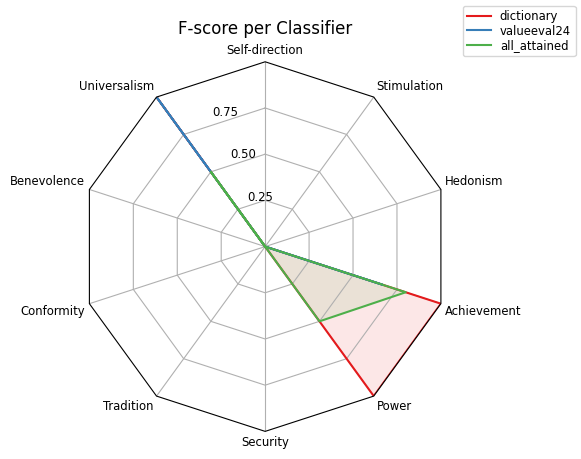

In [53]:
plot = pyvalues.OriginalValues.plot_all(list(fs.values()), labels=list(fs.keys()))
plot.title("F-score per Classifier", pad=20);

## Conclusion

This tutorial showed how to use the `pyvalues` library and different classifiers to classify segments and documents according to human values schemas. Moreover, it showed how to post-process and visualize the classifications, as well as how to evaluate classifications.

## References

Legkas, S., Christodoulou, C., Zidianakis, M., Koutrintzes, D., Dagioglou, M., & Petasis, G. (2024). Hierocles of Alexandria at Touché: Multi-task & multi-head custom architecture with transformer-based models for human value detection. In G. Faggioli, N. Ferro, P. Galuscakova, & A. García Seco Herrera (Eds.), Working Notes Papers of the CLEF 2024 Evaluation Labs (Vol. 3740, CEUR Workshop Proceedings, pp. 3419–3432).

Ponizovskiy, V., Ardag, M., Grigoryan, L., Boyd, R., Dobewall, H., Holtz, P. (2022). Development and Validation of the Personal Values Dictionary: A Theory–Driven Tool for Investigating References to Basic Human Values in Text. European Journal of Personality, 34 (5), 885–902. https://doi.org/10.1002/per.2294


Schwartz, S. H., Cieciuch, J., Vecchione, M., Davidov, E., Fischer, R., Beierlein, C., Ramos, A., Verkasalo, M., Lönnqvist, J. E., Demirutku, K., Dirilen-Gumus, O., & Konty, M. (2012). Refining the theory of basic individual values. Journal of personality and social psychology, 103(4), 663–688. https://doi.org/10.1037/a0029393